In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style as style
from tqdm import tqdm
import math

In [2]:
# --- Data Loading and Initial Cleaning ---
try:
    odds_df = pd.read_csv('odds_2022-2023_v2.csv')
    if 'Unnamed: 0' in odds_df.columns:
        odds_df = odds_df.drop('Unnamed: 0', axis=1)

    goals_df = pd.read_csv("goals_2022-2023.csv")
    goals_df['date'] = pd.to_datetime(goals_df['date']).dt.date
    goals_df['Half Time'] = '0'
    goals_df['Goal Scored'] = 'Yes'
except FileNotFoundError as e:
    print(f"Error loading data files: {e}")
    print("Please ensure 'odds_2022-2023_v2.csv' and 'goals_2022-2023.csv' are in the same directory.")
    exit()


In [3]:
# --- Utility Functions ---
def calc_synth(odds_series):
    """Calculates the harmonic mean for a series of odds."""
    inv_sum = (1 / odds_series).sum()
    if inv_sum == 0:
        return np.nan
    return max(1, 1 / inv_sum)

In [4]:
# --- Match Data Processing ---
def get_match_data(home_team, away_team, odds_data, goals_data):
    """
    Creates a detailed, minute-by-minute dataframe for a single match,
    including odds, goals, and strategy signals.
    """
    match_odds = odds_data[(odds_data['Home Team'] == home_team) & (odds_data['Away Team'] == away_team)].copy()
    
    if match_odds.empty:
        return None

    match_odds['time_key'] = list(zip(match_odds['Elapsed Time'].astype(int), match_odds['Added Time'].astype(int), match_odds['Half Time'].astype(int)))

    norm_mins = [(x, 0, 0) for x in range(0, 91)]
    extra_times = set(match_odds['time_key']) - set(norm_mins)
    all_times = sorted(norm_mins + list(extra_times)) # Combine first, then sort.
    match_timeline = pd.DataFrame(all_times, columns=['Elapsed Time', 'Added Time', 'Half Time'])
    match_timeline['time_key'] = list(zip(match_timeline['Elapsed Time'], match_timeline['Added Time'], match_timeline['Half Time']))


    odds_pivot = match_odds.pivot_table(index='time_key', columns='Selection', values='Last Traded Price')
    
    market_cols = {
        'Real': 'Under 2.5 Goals', 'Over 2.5 Odds': 'Over 2.5 Goals',
        '1-1 Odds': '1 - 1', '2-0 Odds': '2 - 0', '0-2 Odds': '0 - 2',
        '1-0 Odds': '1 - 0', '0-1 Odds': '0 - 1', '0-0 Odds': '0 - 0'
    }
    
    for new_col, original_col in market_cols.items():
        if original_col in odds_pivot.columns:
            match_timeline = match_timeline.merge(odds_pivot[[original_col]], on='time_key', how='left').rename(columns={original_col: new_col})
        else:
            match_timeline[new_col] = np.nan
    
    for col in market_cols.keys():
        still_live = match_timeline[col].notna() & (match_timeline[col] != 1000)
        if still_live.any():
            last_live_idx = still_live[still_live].index[-1]
            match_timeline.loc[last_live_idx + 1:, col] = 1000
        match_timeline[col] = match_timeline[col].ffill().bfill()
        match_timeline[col] = match_timeline[col].replace(1000.0, np.nan)

    synth_components = ['1-1 Odds', '2-0 Odds', '0-2 Odds', '1-0 Odds', '0-1 Odds', '0-0 Odds']
    match_timeline['Synthetic'] = match_timeline[synth_components].apply(calc_synth, axis=1)
    
    match_goals = goals_data[(goals_data['Home Team'] == home_team) & (goals_data['Away Team'] == away_team)].copy()
    if not match_goals.empty:
        match_goals['time_key'] = list(zip(match_goals['Elapsed Time'].astype(int), match_goals['Added Time'].astype(int), match_goals['Half Time'].astype(int)))
        match_timeline = match_timeline.merge(match_goals[['time_key', 'Goal Scored', 'Player', 'Score']], on='time_key', how='left')
    else:
        match_timeline[['Goal Scored', 'Player', 'Score']] = [np.nan, np.nan, np.nan]
        
    match_timeline['Score'] = match_timeline['Score'].ffill().fillna('0-0')
    match_timeline['Goal Scored'] = match_timeline['Goal Scored'].fillna('No')

    # === YOUR STAKING LOGIC RE-IMPLEMENTED (VECTORIZED) ===
    comm = 0.02
    BackOdds = match_timeline['Back Odds'] = match_timeline[['Real', 'Synthetic']].max(axis=1)
    LayOdds = match_timeline['Lay Odds'] = match_timeline[['Real', 'Synthetic']].min(axis=1)

    # To avoid division by zero or other errors if odds are missing
    valid_odds = (BackOdds.notna()) & (LayOdds.notna()) & (LayOdds > 1.0) & (BackOdds > 0)
    
    # Pre-calculate common terms for clarity
    term1 = (LayOdds - comm)
    term2 = ((1 - comm) * BackOdds + comm)
    
    # Calculate stakes only for valid rows
    match_timeline.loc[valid_odds, 'Lay Stake'] = (100 / ((term1 / term2) + LayOdds - 1)).round(1)
    match_timeline.loc[valid_odds, 'Back Stake'] = (100 / (1 + (LayOdds - 1) * (term2 / term1))).round(1)

    match_timeline['Lay'] = np.where(match_timeline['Real'] >= match_timeline['Synthetic'], 'Synthetic', 'Real')
    match_timeline['Real Stake'] = np.where(match_timeline['Lay'] == 'Real', -1 * match_timeline['Lay Stake'], match_timeline['Back Stake'])
    match_timeline['Synth Stake'] = np.where(match_timeline['Lay'] == 'Synthetic', -1 * match_timeline['Lay Stake'], match_timeline['Back Stake'])

    # Calculate profit based on your formula
    match_timeline['Profit'] = ((1 - comm) * match_timeline['Lay Stake'] - match_timeline['Back Stake']).round(2)
    # This profit represents the percentage gain on your £100 liability
    
    def format_time(row):
        if row['Half Time'] > 0: return f"HT+{row['Half Time']}'"
        if row['Added Time'] > 0: return f"{row['Elapsed Time']}+{row['Added Time']}'"
        return f"{row['Elapsed Time']}'"
    match_timeline['plot_label'] = match_timeline.apply(format_time, axis=1)

    return match_timeline


In [5]:
test = get_match_data('Fulham','Brentford',odds_df,goals_df)
test.tail()

,Elapsed Time,Added Time,Half Time,time_key,Real,Over 2.5 Odds,1-1 Odds,2-0 Odds,0-2 Odds,1-0 Odds,...,Score,Back Odds,Lay Odds,Lay Stake,Back Stake,Lay,Real Stake,Synth Stake,Profit,plot_label
108,90,3,0,"(90, 3, 0)",NaN,NaN,NaN,NaN,NaN,NaN,...,3-2,NaN,NaN,NaN,NaN,Real,NaN,NaN,NaN,90+3'
109,90,4,0,"(90, 4, 0)",NaN,NaN,NaN,NaN,NaN,NaN,...,3-2,NaN,NaN,NaN,NaN,Real,NaN,NaN,NaN,90+4'
110,90,5,0,"(90, 5, 0)",NaN,NaN,NaN,NaN,NaN,NaN,...,3-2,NaN,NaN,NaN,NaN,Real,NaN,NaN,NaN,90+5'
111,90,6,0,"(90, 6, 0)",NaN,NaN,NaN,NaN,NaN,NaN,...,3-2,NaN,NaN,NaN,NaN,Real,NaN,NaN,NaN,90+6'
112,90,7,0,"(90, 7, 0)",NaN,NaN,NaN,NaN,NaN,NaN,...,3-2,NaN,NaN,NaN,NaN,Real,NaN,NaN,NaN,90+7'


In [6]:
# --- Graphing Function ---
def plot_match_analysis(match_df, home_team, away_team):
    style.use('seaborn-v0_8-whitegrid')
    fig, ax1 = plt.subplots(figsize=(15, 8))

    ax1.plot(match_df['plot_label'], match_df['Real'], color='royalblue', label='Real Odds (U2.5)', alpha=0.9)
    ax1.plot(match_df['plot_label'], match_df['Synthetic'], color='darkorange', label='Synthetic Odds (U2.5)', linestyle='--')
    ax1.set_xlabel('Match Time')
    ax1.set_ylabel('Odds')
    ax1.tick_params(axis='y')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(match_df['plot_label'], match_df['Profit'], color='mediumseagreen', label='Arbitrage Profit (%)', alpha=0.7)
    ax2.set_ylabel('Arbitrage Profit (% of £100 Liability)', color='mediumseagreen')
    ax2.tick_params(axis='y', labelcolor='mediumseagreen')
    ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax2.legend(loc='upper right')

    tick_indices = np.linspace(0, len(match_df['plot_label']) - 1, 15, dtype=int)
    plt.xticks(match_df['plot_label'][tick_indices], rotation=45, ha="right")
    
    goal_times = match_df[match_df['Goal Scored'] == 'Yes']
    for idx, goal in goal_times.iterrows():
        plt.axvline(x=goal['plot_label'], color='red', linestyle='--', alpha=0.8, label=f"Goal ({goal['Score']})")
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(list(by_label.values()), list(by_label.keys()), loc='best')

    plt.title(f'Match Analysis: {home_team} vs {away_team}', fontsize=16)
    fig.tight_layout()
    plt.show()

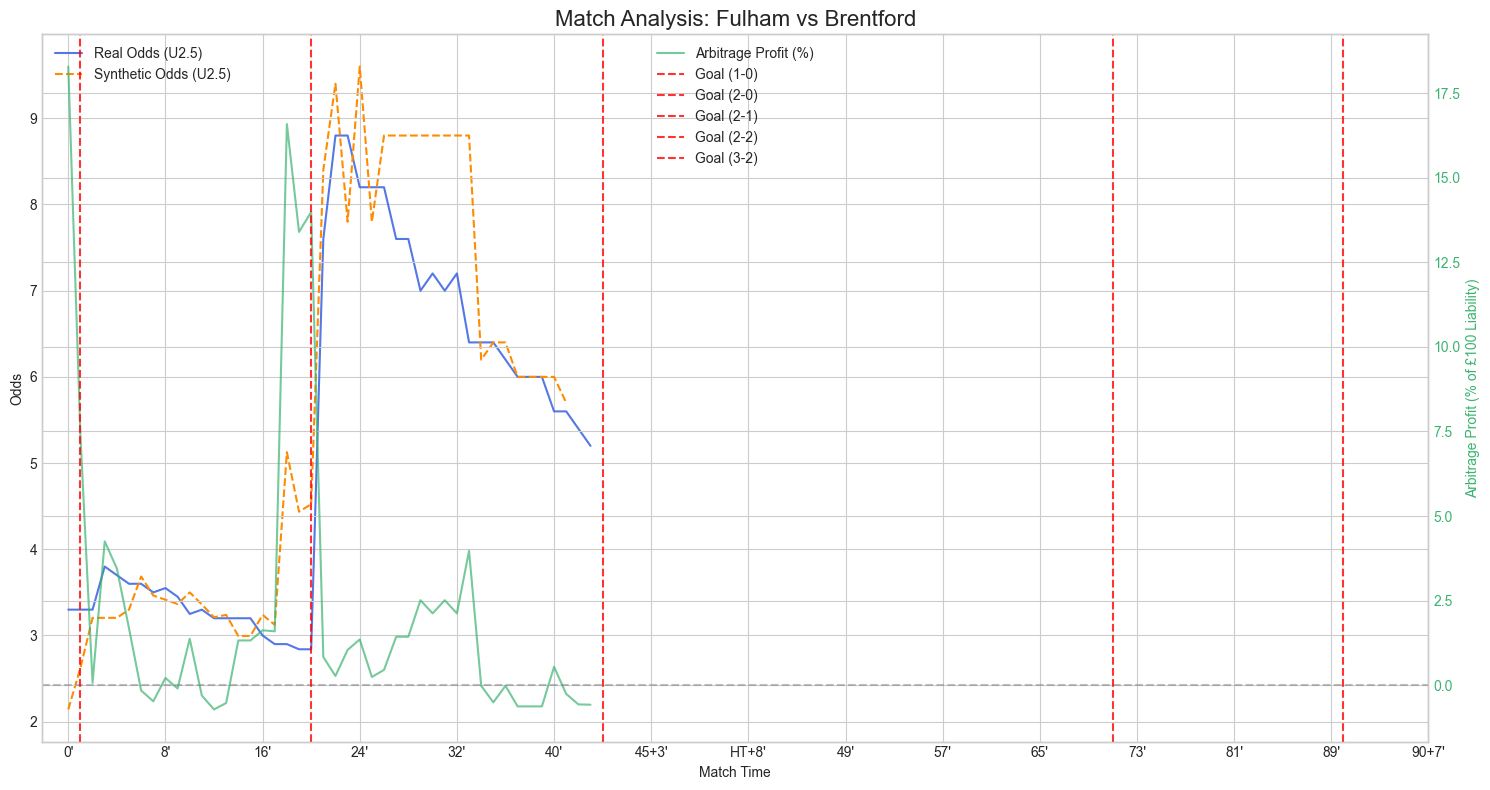

In [7]:
plot_match_analysis(test, 'Fulham', 'Brentford')

In [17]:
# --- Strategy function ---
def crossover_strategy(row, prev_pos, entry_threshold=0.0):
    """
    A strategy that enters a trade when profit is above a threshold and
    exits when the odds have crossed over against the position.
    """
    if pd.isna(row['Profit']) or pd.isna(row['Real']) or pd.isna(row['Synthetic']):
        return 'Hold'

    in_trade = prev_pos != (0, 0, 0)
    arbitrage_exists = row['Profit'] > entry_threshold
    real_minus_synth = row['Real'] - row['Synthetic']
    
    if not in_trade and arbitrage_exists:
        return 'Trade'
    
    elif in_trade and (real_minus_synth * prev_pos[0] < 0):
        return 'Clear'
        
    else:
        return 'Hold'

In [18]:
# --- BACKTESTING ENGINE ---
def update_position(instruction, prev_pos, row):
    """Updates the position based on the instruction from the strategy."""
    if instruction == 'Trade':
        return (row['Real Stake'], row['Synth Stake'], row['Profit'])
    elif instruction == 'Clear':
        return (0, 0, 0)
    else: # Hold
        return prev_pos

def update_pnl(instruction, prev_pnl, prev_pos):
    """Updates the cumulative Profit and Loss."""
    if instruction == 'Clear':
        return prev_pnl + abs(prev_pos[2])
    else:
        return prev_pnl

def run_backtest(match_data, strategy_function, entry_threshold=0.0):
    """
    A generic backtesting engine that iterates through a match and applies
    a given strategy function to calculate profit and loss.
    """
    pnl = 0.0
    position = (0, 0, 0)
    
    for i, row in match_data.iterrows():
        instruction = strategy_function(row, position, entry_threshold)
        pnl = update_pnl(instruction, pnl, position)
        position = update_position(instruction, position, row)
        
    if position != (0, 0, 0):
        pnl += abs(position[2])

    return pnl

In [19]:
def analyse_single_match(home_team, away_team, odds_data, goals_data, strategy_func, entry_threshold=0.0):
    """Performs a full analysis on a single match."""
    print(f"\n--- Analyzing Single Match: {home_team} vs {away_team} ---")
    match_data = get_match_data(home_team, away_team, odds_data, goals_data)
    if match_data is None:
        print("Could not find data for this match.")
        return
    profit = run_backtest(match_data, strategy_func, entry_threshold)
    print(f"Calculated Profit using '{strategy_func.__name__}': {profit:.2f}%")
    plot_match_analysis(match_data, home_team, away_team)


--- Analyzing Single Match: Fulham vs Brentford ---
Calculated Profit using 'crossover_strategy': 23.75%


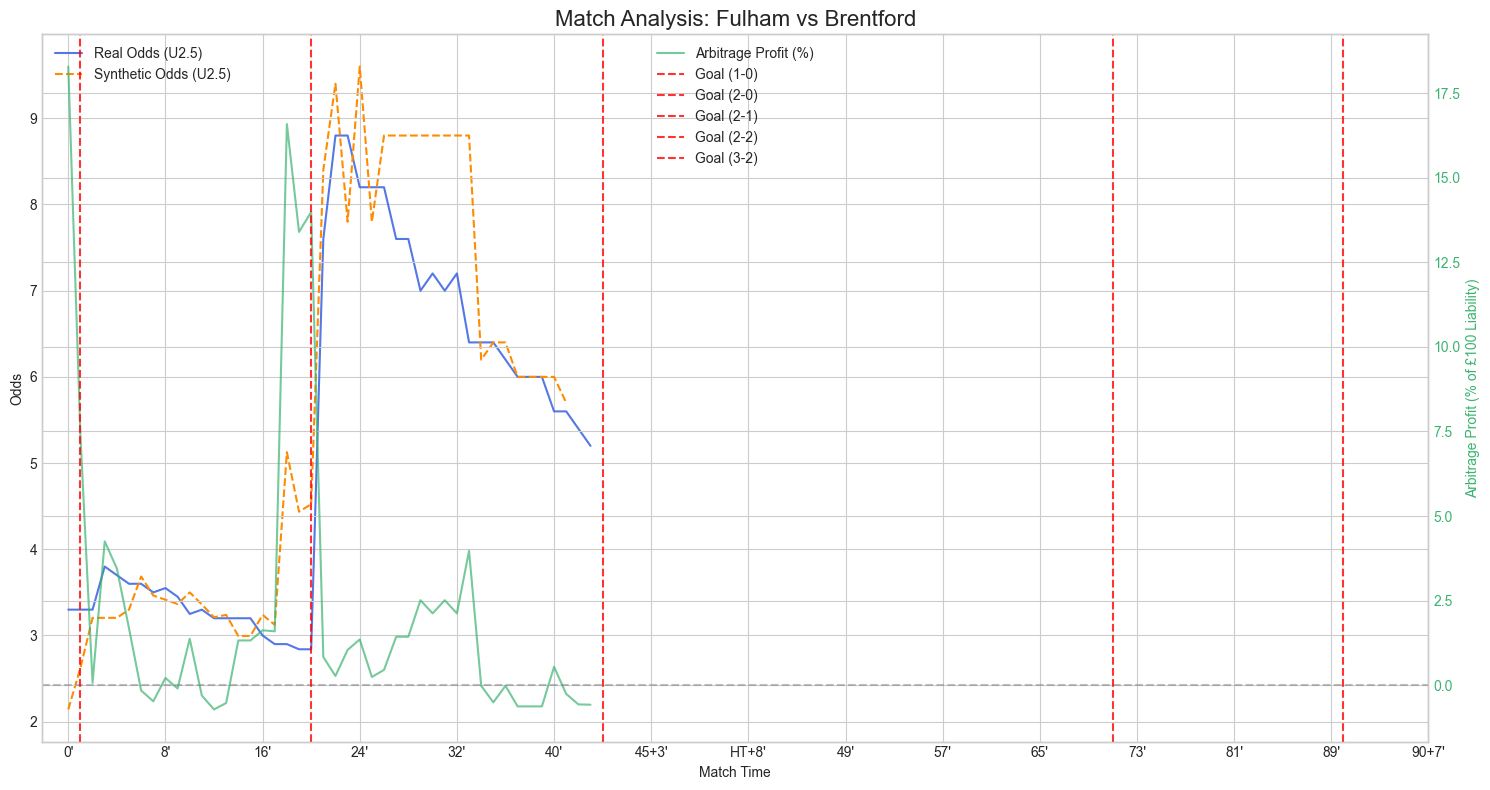

In [20]:
analyse_single_match("Fulham", 'Brentford', odds_df, goals_df, crossover_strategy, entry_threshold=0.0)

In [21]:
def run_season_analysis(strategy_func, entry_threshold=0.0):
    """
    Runs the full backtest across all matches and provides a statistical summary.
    This version handles matches with missing dates to prevent plotting errors.
    """
    print(f"--- Starting Full Season Backtest using '{strategy_func.__name__}' ---")
    matches = odds_df[['Home Team', 'Away Team']].drop_duplicates()
    match_dates = goals_df.groupby(['Home Team', 'Away Team'])['date'].first().reset_index()
    matches = pd.merge(matches, match_dates, on=['Home Team', 'Away Team'], how='left') # Keep the left merge
    
    profits = []
    for index, row in tqdm(matches.iterrows(), total=matches.shape[0], desc="Backtesting All Matches"):
        home, away = row['Home Team'], row['Away Team']
        # The date is carried through but not used in the backtest itself
        match_data = get_match_data(home, away, odds_df, goals_df)
        if match_data is not None:
            profit = run_backtest(match_data, strategy_func, entry_threshold)
            profits.append({'match_id': f"{home}_vs_{away}", 'profit': profit, 'date': row['date']})
            
    profit_df = pd.DataFrame(profits)

    # --- Statistical Summary (on ALL processed matches) ---
    print("\n--- Strategy Performance Summary (Full Season) ---")

    total_profit = profit_df['profit'].sum()
    num_matches = len(profit_df)
    profitable_matches = profit_df[profit_df['profit'] > 0]
    num_profitable = len(profitable_matches)

    # Sort by profit in descending order to get the top matches
    profit_df.sort_values(by="profit", ascending=False, inplace=True)

    # --- Print Summary ---
    print(f"Total Matches Analyzed: {num_matches}")
    print(f"Total Net Profit: {total_profit:.2f}%")
    print(f"Average Profit per Match: {profit_df['profit'].mean():.4f}%")
    print(f"Profitable Matches: {num_profitable} ({(num_profitable/num_matches)*100:.2f}%)")

    print("\n--- Top 3 Most Profitable Matches ---")
    # Reset index to ensure .loc[i] works as expected
    profit_df.reset_index(drop=True, inplace=True) 

    # Loop through the top 3 rows of the sorted DataFrame
    for i in range(3):
        # Check if there are enough matches to display
        if i < len(profit_df):
            match_id = profit_df["match_id"].loc[i]
            profit = profit_df["profit"].loc[i]
            print(f"Top {i+1} profit was for match {match_id} with {profit:.2f}%")
    if num_matches > 0:
        print(f"Win Rate: {(num_profitable / num_matches) * 100:.2f}%")
    sharpe_ratio = profit_df['profit'].mean() / profit_df['profit'].std() if profit_df['profit'].std() != 0 else 0
    print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

    # --- Chronological & Visual Analysis (on matches WITH dates) ---
    
    # FIX: Create a clean dataframe for plotting, removing rows with no date.
    plot_df = profit_df.dropna(subset=['date']).copy()
    plot_df = plot_df.sort_values('date')

    if not plot_df.empty:
        # a) Cumulative Profit Over Time
        plot_df['cumulative_profit'] = plot_df['profit'].cumsum()
        plt.figure(figsize=(15, 7))
        # Use the clean plot_df for plotting
        plt.plot(plot_df['date'], plot_df['cumulative_profit'], marker='o', linestyle='-')
        plt.title('Cumulative Strategy Profit Over Season', fontsize=16)
        plt.xlabel('Date'); plt.ylabel('Cumulative Profit (%)'); plt.grid(True); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
    else:
        print("\nNo matches with valid dates found to create a cumulative profit plot.")

    # b) Histogram of Profit per Match (can use all data)
    plt.figure(figsize=(15, 7))
    plt.hist(profit_df['profit'], bins=50, color='skyblue', edgecolor='black')
    plt.axvline(profit_df['profit'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: {profit_df['profit'].mean():.4f}%")
    plt.title('Distribution of Profit Per Match', fontsize=16)
    plt.xlabel('Profit (%)'); plt.ylabel('Number of Matches'); plt.legend(); plt.grid(True); plt.show()

--- Starting Full Season Backtest using 'crossover_strategy' ---


Backtesting All Matches: 100%|██████████| 377/377 [01:08<00:00,  5.48it/s]



--- Strategy Performance Summary (Full Season) ---
Total Matches Analyzed: 377
Total Net Profit: 11342.87%
Average Profit per Match: 30.0872%
Profitable Matches: 377 (100.00%)

--- Top 3 Most Profitable Matches ---
Top 1 profit was for match Southampton_vs_Brentford with 499.58%
Top 2 profit was for match Chelsea_vs_Manchester United with 361.50%
Top 3 profit was for match Everton_vs_Arsenal with 157.81%
Win Rate: 100.00%
Sharpe Ratio: 0.78


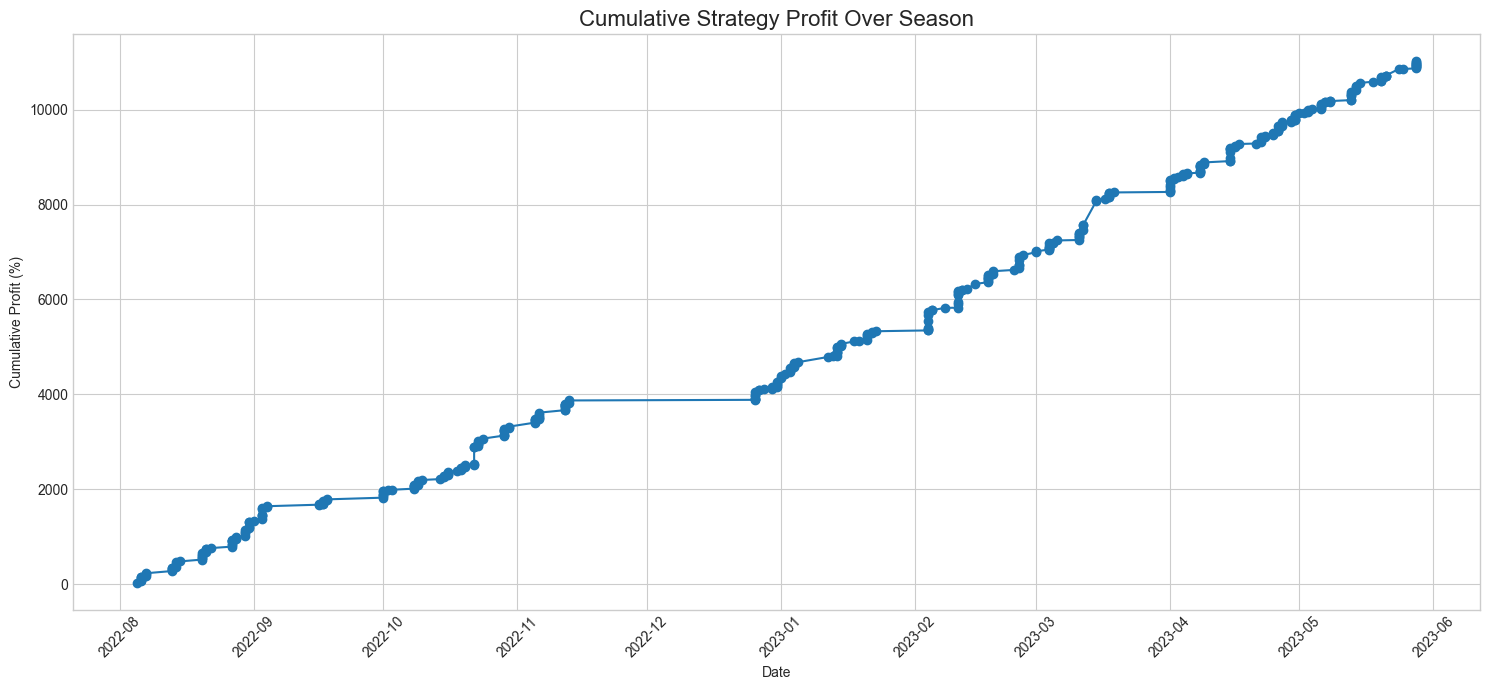

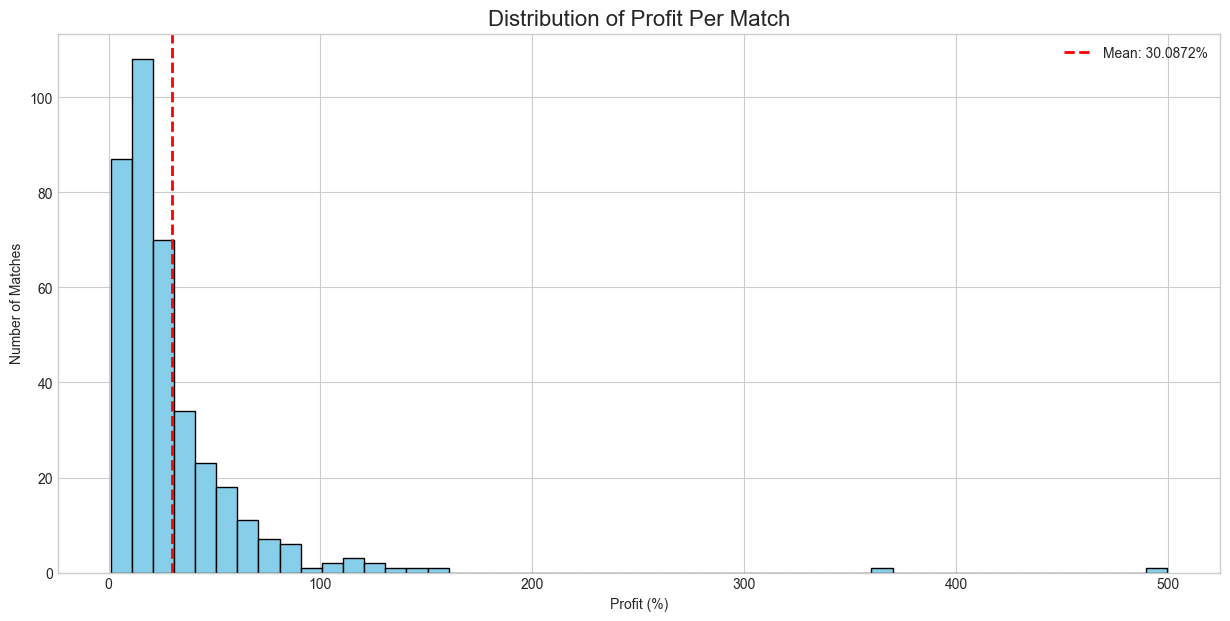

In [22]:

strategy_to_test = crossover_strategy
entry_signal = 0 # e.g., only trade if profit is > 0.5%



# --- Run the full season analysis ---
# Comment out the line above and un-comment the line below to run the full backtest.
run_season_analysis(strategy_func=strategy_to_test, entry_threshold=entry_signal)


--- Analyzing Single Match: Brighton vs Fulham ---
Calculated Profit using 'crossover_strategy': 762.77%


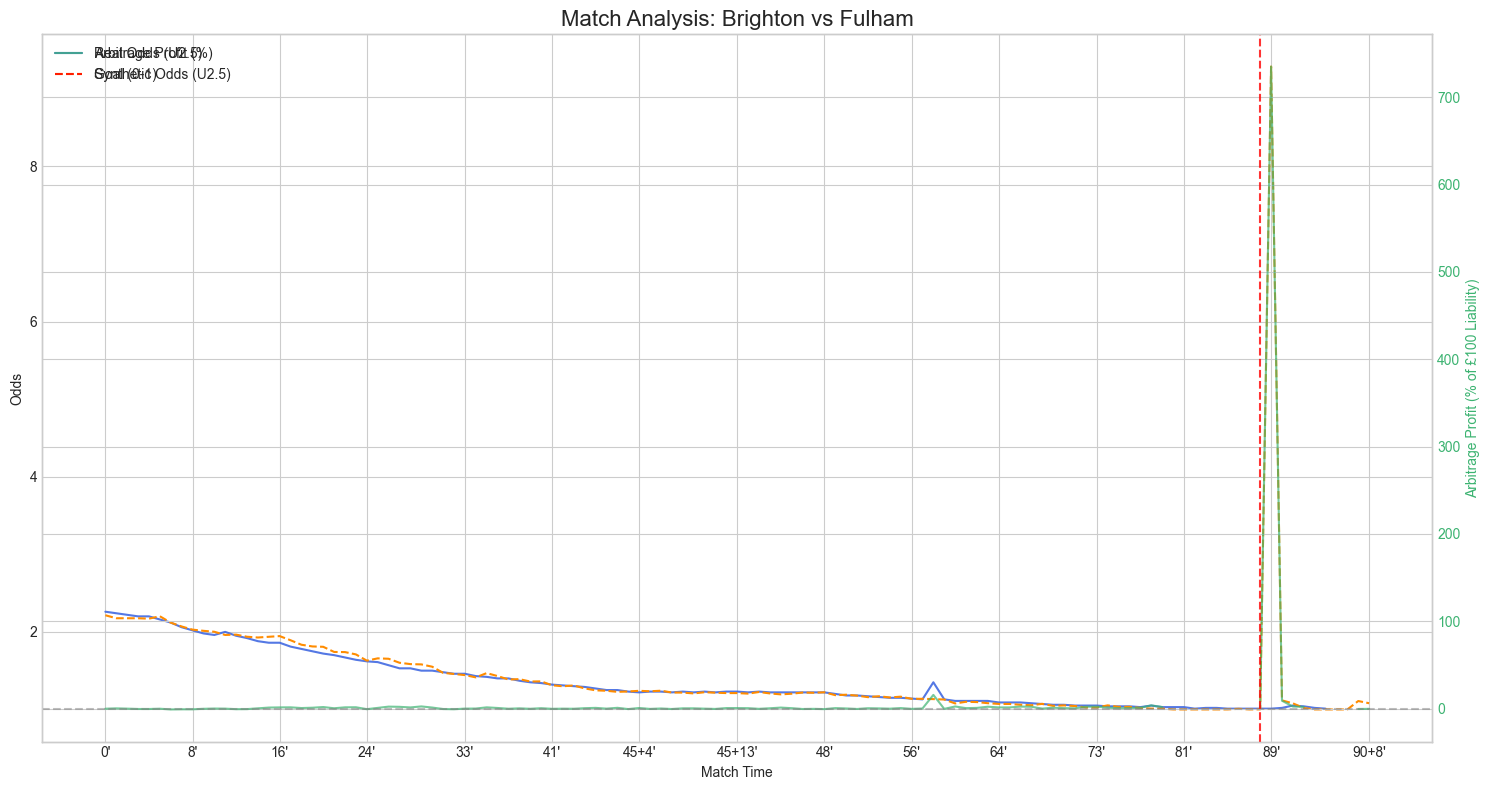

In [16]:
# --- Analyze a single match ---
# Un-comment the line below to run the analysis for a specific game.
analyse_single_match('Brighton', 'Fulham', odds_df, goals_df, strategy_func=strategy_to_test,entry_threshold=entry_signal)